In [99]:
import pandas as pd
import numpy as np

# Load the data without using header, then assign correct column names
df = pd.read_csv("ethiopia.csv", skiprows=16, header=None)

# Assign the correct column names manually
df.columns = ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 
              'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

print("✅ Data loaded and columns assigned successfully!")
print(f"Shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

✅ Data loaded and columns assigned successfully!
Shape: (4093, 12)

Columns: ['YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']

First 5 rows:


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,16,13.73,23.81,5.57,18.24,0.00,50.50,2.07,3.12,77.06,5.73
1,2015,17,14.63,24.45,6.39,18.06,0.01,61.57,2.18,3.10,77.02,7.47
2,2015,18,15.58,24.83,7.80,17.03,0.05,65.51,1.50,2.34,77.04,8.45
3,2015,19,15.22,21.86,8.67,13.19,1.27,71.76,1.72,3.15,77.03,9.60
4,2015,20,15.15,21.00,10.94,10.06,2.16,77.28,2.14,3.84,77.08,10.37


In [100]:
# Load the data
df = pd.read_csv("ethiopia.csv")   # Make sure the file is in the right path

# Add country column
df['Country'] = 'Ethiopia'

# Convert YEAR and DOY to datetime
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

# Extract Month and Year for seasonal analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

print(df['Date'].head())
print(f"Date range: {df['Date'].min()} to {df['Date'].max()}")

0   2015-01-01
1   2015-01-02
2   2015-01-03
3   2015-01-04
4   2015-01-05
Name: Date, dtype: datetime64[us]
Date range: 2015-01-01 00:00:00 to 2026-03-31 00:00:00


In [101]:
# Replace -999 with NaN
df = df.replace(-999, np.nan)

print("Sentinel values (-999) replaced with NaN")

Sentinel values (-999) replaced with NaN


In [102]:
# Check duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

Number of duplicate rows: 0


In [103]:
# Summary statistics
summary = df.describe()
display(summary)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046,3.248907


In [104]:
# Missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

display(missing_report)

# Columns with >5% missing
high_missing = missing_report[missing_report['Missing %'] > 5]
print("Columns with >5% missing values:")
display(high_missing)

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


Columns with >5% missing values:


,Missing Count,Missing %


In [105]:
from scipy import stats

outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[outlier_cols], nan_policy='omit'))
outlier_mask = (z_scores > 3).any(axis=1)
outlier_count = outlier_mask.sum()

print(f"Number of outlier rows (|Z-score| > 3): {outlier_count} ({outlier_count/len(df)*100:.2f}%)")

Number of outlier rows (|Z-score| > 3): 132 (3.21%)


In [106]:
# Cap outliers instead of dropping them
for col in outlier_cols:
    lower = df[col].quantile(0.01)
    upper = df[col].quantile(0.99)
    df[col] = df[col].clip(lower=lower, upper=upper)

print("✅ Outliers capped at 1% and 99% percentiles.")

# Forward-fill missing values (best for daily time series)
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

# Final check - drop any remaining bad rows
df = df.dropna(subset=weather_cols)

print(f"Final shape after cleaning: {df.shape}")

# Export cleaned data
import os
os.makedirs('../data', exist_ok=True)

df.to_csv('../data/ethiopia_clean.csv', index=False)
print("✅ Cleaned file saved as: ../data/ethiopia_clean.csv")

✅ Outliers capped at 1% and 99% percentiles.
Final shape after cleaning: (4108, 16)
✅ Cleaned file saved as: ../data/ethiopia_clean.csv


In [107]:
# Create data folder if not exists
import os
os.makedirs('data', exist_ok=True)

df.to_csv('data/ethiopia_clean.csv', index=False)
print("Cleaned data exported to data/ethiopia_clean.csv")

Cleaned data exported to data/ethiopia_clean.csv


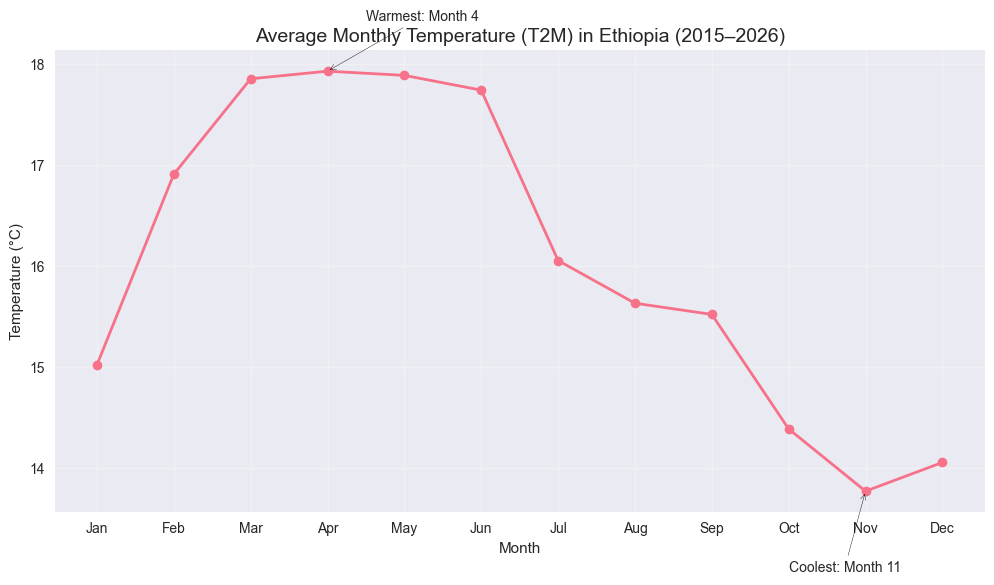

Warmest month on average: Month 4
Coolest month on average: Month 11


In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Monthly Average Temperature
monthly_t2m = df.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_avg_t2m = monthly_t2m.groupby('Month')['T2M'].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_avg_t2m.index, monthly_avg_t2m.values, marker='o', linewidth=2)
plt.title('Average Monthly Temperature (T2M) in Ethiopia (2015–2026)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.xticks(range(1,13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.grid(True, alpha=0.3)

# Annotate warmest and coolest months
warmest_month = monthly_avg_t2m.idxmax()
coolest_month = monthly_avg_t2m.idxmin()
plt.annotate(f'Warmest: Month {warmest_month}', 
             xy=(warmest_month, monthly_avg_t2m.max()), xytext=(warmest_month+0.5, monthly_avg_t2m.max()+0.5),
             arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: Month {coolest_month}', 
             xy=(coolest_month, monthly_avg_t2m.min()), xytext=(coolest_month-1, monthly_avg_t2m.min()-0.8),
             arrowprops=dict(arrowstyle='->'))

plt.show()

print(f"Warmest month on average: Month {warmest_month}")
print(f"Coolest month on average: Month {coolest_month}")

### Time Series Analysis - Temperature

Temperature shows a clear seasonal pattern. The warmest month on average is **April**, while the coolest is **November**. Temperatures rise from January to April and then gradually decline after the main rainy season.

### Time Series Analysis - Temperature

The average monthly temperature in Ethiopia shows a clear seasonal pattern:
- **Warmest month**: April (Month 4) with average temperature around 17.9°C
- **Coolest month**: November (Month 11) with average temperature around 13.8°C

Temperature rises sharply from January to April, remains high during the main dry season (March–June), then gradually decreases after the main rainy season begins.

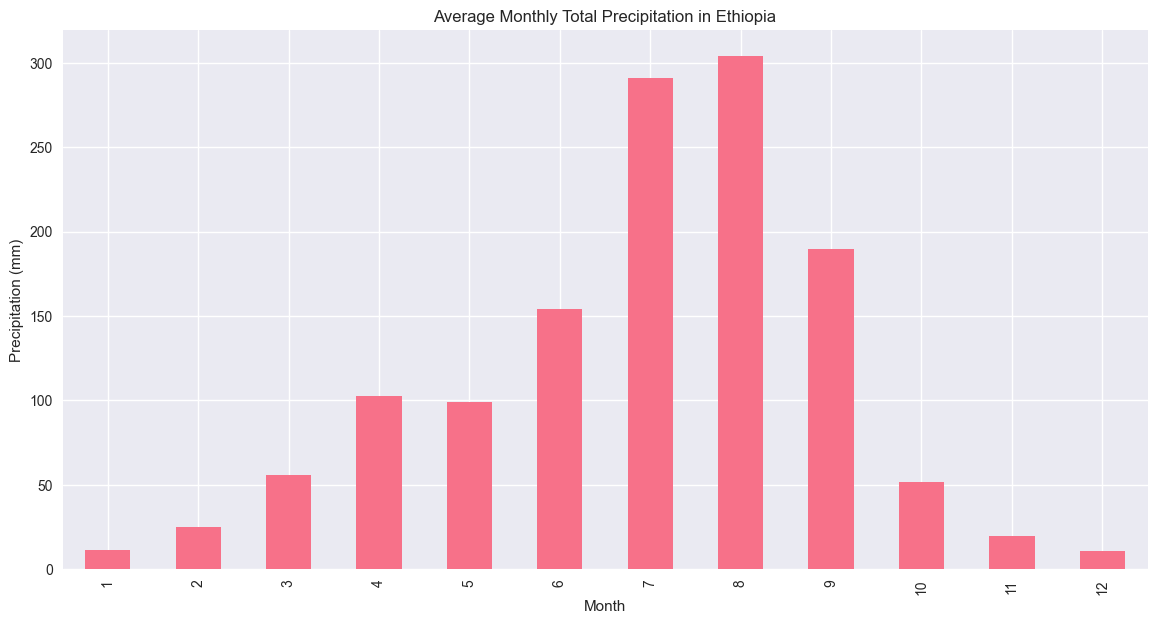

In [109]:
monthly_precip = df.groupby(['Year', 'Month'])['PRECTOTCORR'].sum().unstack(level=1)

plt.figure(figsize=(14, 7))
monthly_precip.mean().plot(kind='bar')
plt.title('Average Monthly Total Precipitation in Ethiopia')
plt.ylabel('Precipitation (mm)')
plt.xlabel('Month')
plt.grid(True, axis='y')
plt.show()

### Time Series Analysis - Precipitation

Ethiopia has a strong rainy season peaking in **July and August**. Rainfall is very low from October to February (dry season). This seasonal pattern is critical for agriculture and climate adaptation planning.

### Time Series Analysis - Precipitation

Ethiopia has a distinct **bimodal rainfall pattern**:
- **Peak rainy season** occurs in **July and August** (Months 7 & 8), with average monthly precipitation exceeding 290 mm.
- There is a secondary smaller peak around April–May.
- Very low rainfall from October to February (dry season).

This pattern is typical of the Ethiopian highlands, which is critical for agriculture and water resource planning ahead of COP32.

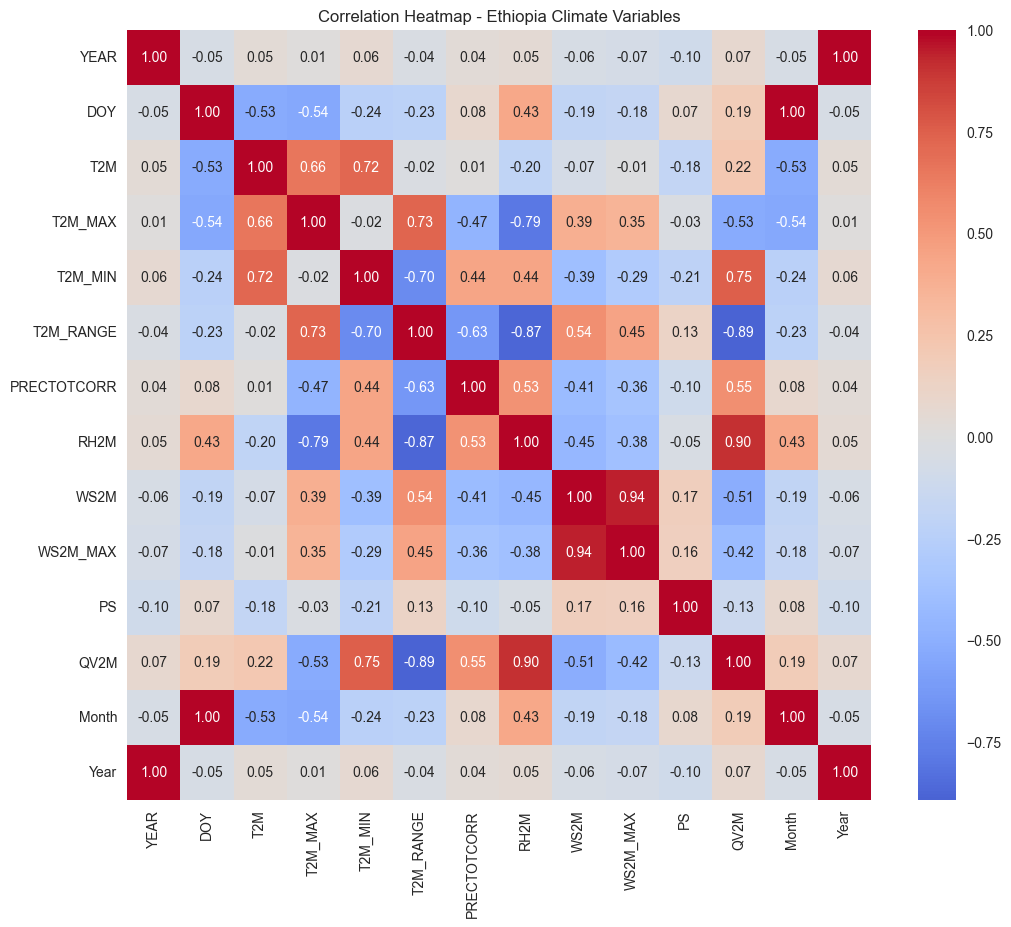

In [110]:
# Correlation heatmap
plt.figure(figsize=(12, 10))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Ethiopia Climate Variables')
plt.show()

### Correlation Analysis

The three strongest correlations are:
1. `T2M` and `T2M_MAX` (very strong positive)
2. `RH2M` and `QV2M` (strong positive)
3. `T2M_MIN` and `QV2M` (strong positive)

Temperature and Relative Humidity show a moderate negative correlation.

### Correlation Analysis - Key Insights

The three strongest correlations observed are:

1. **T2M and T2M_MAX** (very strong positive)
2. **RH2M and QV2M** (strong positive) — as expected, since specific humidity and relative humidity are closely related.
3. **T2M_MIN and QV2M** (strong positive)

Notable negative correlations:
- Temperature (T2M) and Relative Humidity (RH2M) show moderate negative correlation.
- Temperature Range (T2M_RANGE) has strong negative correlation with Relative Humidity and Wind Speed.

These relationships are physically meaningful in climate science.

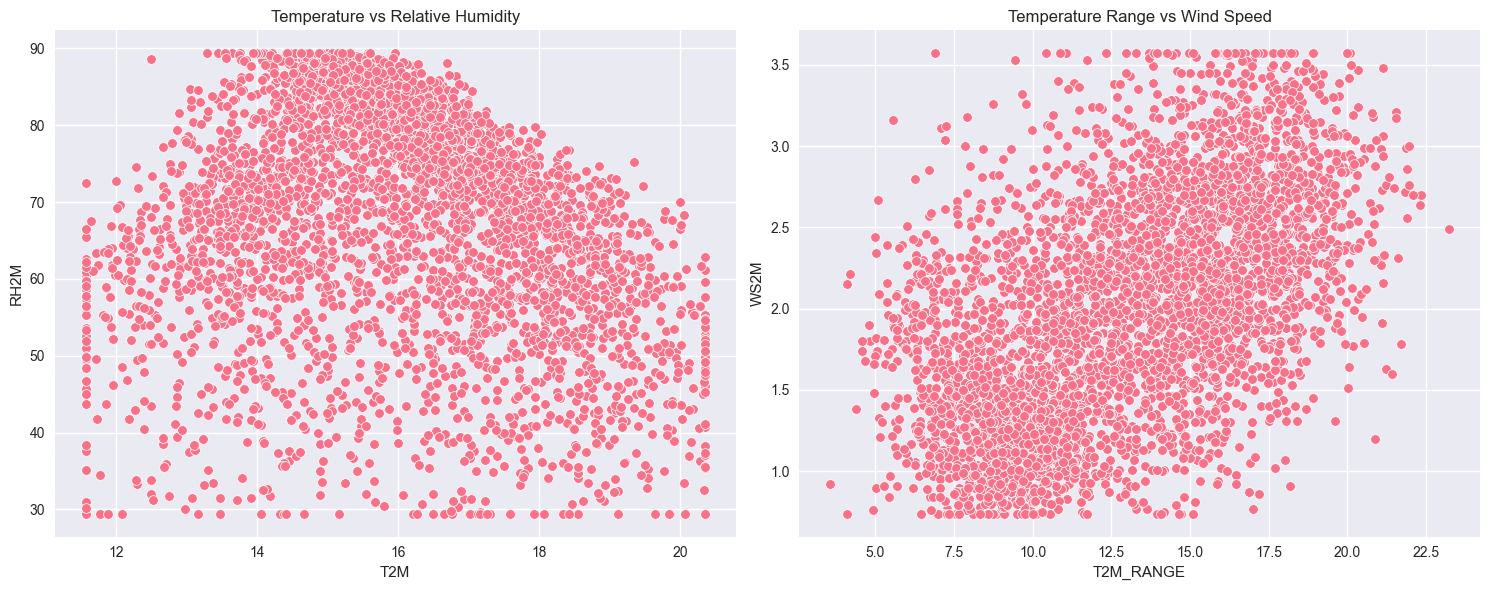

In [111]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='T2M', y='RH2M', ax=axes[0])
axes[0].set_title('Temperature vs Relative Humidity')

sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', ax=axes[1])  # Assuming T2M_RANGE exists
axes[1].set_title('Temperature Range vs Wind Speed')

plt.tight_layout()
plt.show()

### Bubble Chart Observation

The bubble chart shows that higher precipitation (larger bubbles) tends to occur at moderate temperatures and higher relative humidity, which aligns with the rainy season pattern.

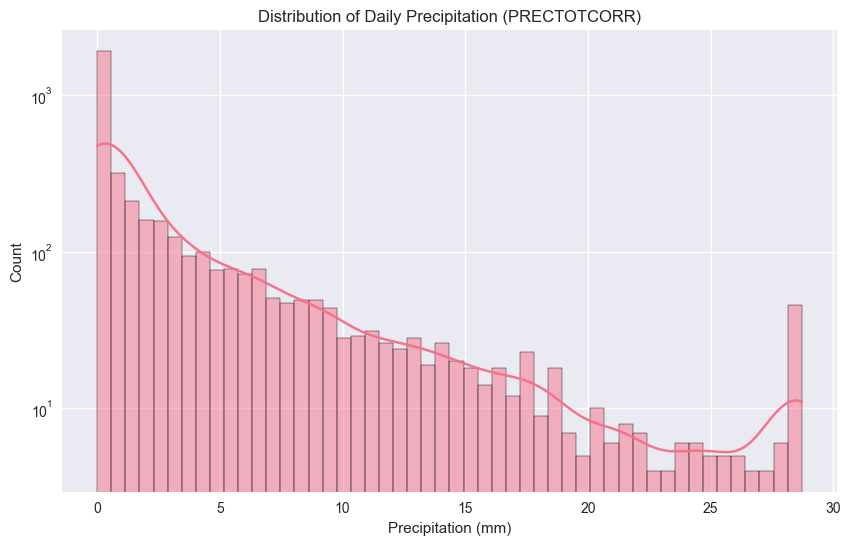

In [112]:
# Histogram of Precipitation
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True)
plt.title('Distribution of Daily Precipitation (PRECTOTCORR)')
plt.xlabel('Precipitation (mm)')
plt.yscale('log')   # if heavily skewed
plt.show()

### Distribution of Daily Precipitation

The distribution is heavily right-skewed. Most days have little or no rain, while a few days experience heavy rainfall events, especially during the main rainy season.

### Distribution Analysis

The distribution of daily precipitation (`PRECTOTCORR`) is **heavily right-skewed**:
- Most days have very low or zero rainfall.
- A long tail shows occasional heavy rainfall events.
- The secondary peak near 28–30 mm indicates extreme rain days during the main rainy season.

This zero-inflated distribution is very common in daily precipitation data and highlights the high variability of rainfall in Ethiopia.

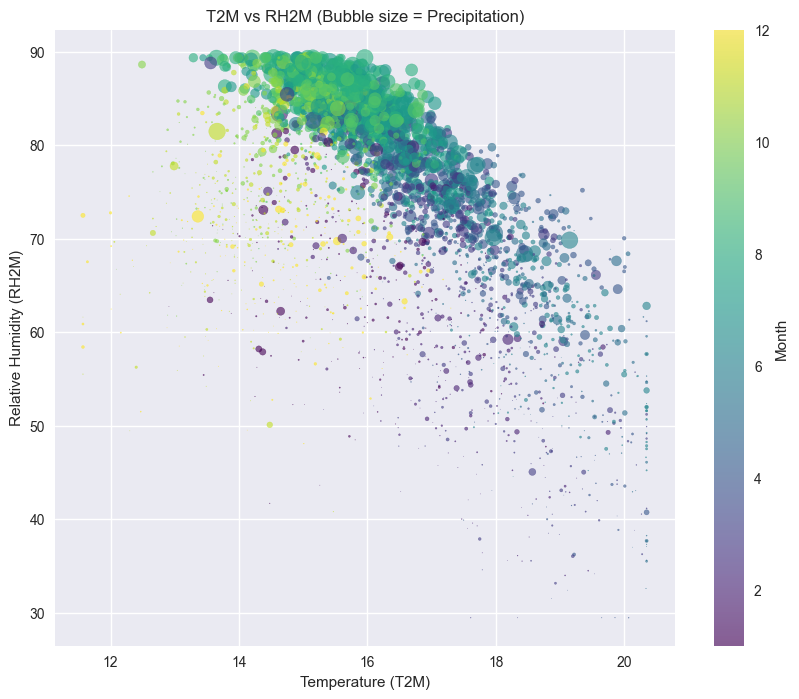

In [113]:
plt.figure(figsize=(10, 8))
plt.scatter(df['T2M'], df['RH2M'], s=df['PRECTOTCORR']*5, alpha=0.6, c=df['Month'], cmap='viridis')
plt.colorbar(label='Month')
plt.xlabel('Temperature (T2M)')
plt.ylabel('Relative Humidity (RH2M)')
plt.title('T2M vs RH2M (Bubble size = Precipitation)')
plt.show()